# Layer-1 Baseline + fclass Feature

Reproduces `layer1.ipynb` end-to-end (2020 baseline → multi-year → enhanced temporal → graph neighbors → XGBoost → grouped CV) but adds `fclass` (road functional class) as a one-hot feature throughout all model stages.

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

def find_repo_root(start: Path | None = None, repo_name: str = "Sentinel-FYP") -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == repo_name:
            return candidate
    raise FileNotFoundError(f"Could not find repo root named {repo_name!r} from {start}")

ROOT = find_repo_root()
DATA_DIR = ROOT / "data"
S2_2020_DIR = DATA_DIR / "ghana_parquet" / "year=2020"

pbf_candidates = sorted(DATA_DIR.glob("*.osm.pbf"))
PBF_PATH = pbf_candidates[-1] if pbf_candidates else None

print("Repo root:", ROOT)
print("Data dir:", DATA_DIR)
print("2020 parquet dir exists:", S2_2020_DIR.exists())
print("PBF:", PBF_PATH if PBF_PATH else "(not found)")

from sklearn.metrics import matthews_corrcoef
from sklearn.inspection import permutation_importance
from scipy.stats import wilcoxon

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except Exception:
    lgbm_available = False
    print('LightGBM not installed; run: pip install lightgbm')

try:
    import shap
    shap_available = True
except Exception:
    shap_available = False
    print('SHAP not installed; run: pip install shap')


Repo root: /Users/miranda/Documents/GitHub/Sentinel-FYP
Data dir: /Users/miranda/Documents/GitHub/Sentinel-FYP/data
2020 parquet dir exists: True
PBF: /Users/miranda/Documents/GitHub/Sentinel-FYP/data/ghana-260415.osm.pbf


In [2]:
if not S2_2020_DIR.exists():
    raise FileNotFoundError(f"Missing directory: {S2_2020_DIR}")

parquet_files = sorted(S2_2020_DIR.glob("*.parquet"))
if not parquet_files:
    raise FileNotFoundError(f"No parquet files found in {S2_2020_DIR}")

# Keep behaviour stable with project convention: first file per year
s2_2020 = pd.read_parquet(parquet_files[0]).copy()
s2_2020["osm_id"] = s2_2020["osm_id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

idx_cols = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
for c in idx_cols:
    s2_2020[c] = pd.to_numeric(s2_2020[c], errors="coerce")

s2_2020 = s2_2020.dropna(subset=idx_cols, how="all").copy()

print("2020 rows:", len(s2_2020))
print("2020 unique osm_id:", s2_2020["osm_id"].nunique())
s2_2020.head(3)

2020 rows: 1230289
2020 unique osm_id: 326546


,osm_id,fclass,quarter,NDVI,NDMI,NDBI,NDWI,BSI
0,520162721,trunk,Q1,0.157278,-0.142099,0.142099,-0.269918,0.183079
1,574240962,trunk,Q1,0.089044,-0.130132,0.130132,-0.173877,0.156009
2,574240965,trunk,Q1,0.058767,-0.161057,0.161057,-0.144965,0.174362


In [3]:
import gc

try:
    from pyrosm import OSM
except Exception as e:
    raise ImportError("pyrosm is required. Install with: pip install pyrosm") from e

if PBF_PATH is None or not PBF_PATH.exists():
    raise FileNotFoundError("No .osm.pbf file found in data/")

osm = OSM(str(PBF_PATH))
roads_osm = osm.get_network(network_type="driving").copy()
del osm  # free the ~1-2 GB parsed PBF data immediately
gc.collect()

roads_osm["osm_id"] = roads_osm["id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
roads_osm["surface_clean"] = roads_osm["surface"].astype(str).str.lower().str.strip()
roads_osm["road_name_clean"] = roads_osm.get("name", pd.Series(index=roads_osm.index, dtype="object")).astype(str).str.strip()
roads_osm.loc[roads_osm["road_name_clean"].isin(["", "nan", "None"]), "road_name_clean"] = np.nan

focus_classes = ["residential", "service", "trunk", "primary", "secondary", "tertiary", "unclassified"]
roads_osm = roads_osm[roads_osm["highway"].isin(focus_classes)].copy()

paved_vals = {"paved", "asphalt", "concrete", "paving_stones", "concrete:plates", "sett", "cobblestone", "metal", "bricks", "cement", "chipseal"}
unpaved_vals = {"unpaved", "ground", "dirt", "earth", "gravel", "fine_gravel", "sand", "mud", "grass", "compacted", "pebblestone", "soil"}

roads_osm["layer1_label_large"] = np.where(
    roads_osm["surface_clean"].isin(paved_vals), "paved",
    np.where(roads_osm["surface_clean"].isin(unpaved_vals), "unpaved", None)
)

name_known = roads_osm.dropna(subset=["road_name_clean", "layer1_label_large"]).copy()
name_stats = (
    name_known.groupby("road_name_clean")["layer1_label_large"]
    .agg(lambda s: sorted(set(s.dropna().tolist())))
    .to_frame("classes")
)
name_stats["n_classes"] = name_stats["classes"].apply(len)
name_stats["inferred_label"] = np.where(
    name_stats["n_classes"] == 1,
    name_stats["classes"].apply(lambda x: x[0]),
    np.nan,
)
name_to_label = name_stats["inferred_label"].dropna()

missing_before = roads_osm["layer1_label_large"].isna().sum()
fill_mask = roads_osm["layer1_label_large"].isna() & roads_osm["road_name_clean"].notna()
roads_osm.loc[fill_mask, "layer1_label_large"] = roads_osm.loc[fill_mask, "road_name_clean"].map(name_to_label)
missing_after = roads_osm["layer1_label_large"].isna().sum()

label_df_large = roads_osm[["osm_id", "highway", "layer1_label_large"]].copy()
label_df_large = label_df_large[label_df_large["layer1_label_large"].isin(["paved", "unpaved"])].drop_duplicates(subset=["osm_id"])
label_df_large = label_df_large.rename(columns={"highway": "fclass"})

# Trim roads_osm to only what's needed later (geometry for section 7, name for grouped CV)
roads_osm = roads_osm[["osm_id", "geometry", "name"]].copy()
gc.collect()

print("PBF used:", PBF_PATH.name)
print("Named-road labels filled:", int(missing_before - missing_after))
print("Large label rows:", len(label_df_large))
print("Large label balance (%):")
print(label_df_large["layer1_label_large"].value_counts(normalize=True).mul(100).round(2))

/opt/anaconda3/envs/sentinel/lib/python3.11/site-packages/pyrosm/networks.py:37: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  edges, nodes = prepare_geodataframe(


PBF used: ghana-260415.osm.pbf
Named-road labels filled: 1784
Large label rows: 31650
Large label balance (%):
layer1_label_large
unpaved    54.61
paved      45.39
Name: proportion, dtype: float64


In [4]:
df_q_large = s2_2020.merge(label_df_large[["osm_id", "layer1_label_large"]], on="osm_id", how="inner")

print("Quarterly merged rows:", len(df_q_large))
print("Quarterly unique roads:", df_q_large["osm_id"].nunique())

road_feats_large = (
    df_q_large.groupby(["osm_id", "layer1_label_large"], as_index=False)
    .agg(
        NDVI_mean=("NDVI", "mean"), NDVI_std=("NDVI", "std"),
        NDMI_mean=("NDMI", "mean"), NDMI_std=("NDMI", "std"),
        NDBI_mean=("NDBI", "mean"), NDBI_std=("NDBI", "std"),
        NDWI_mean=("NDWI", "mean"), NDWI_std=("NDWI", "std"),
        BSI_mean=("BSI", "mean"),  BSI_std=("BSI", "std"),
    )
)

# Add fclass (road functional class) from parquet — most frequent class per road
fclass_mode = (
    df_q_large[["osm_id", "fclass"]]
    .dropna(subset=["fclass"])
    .groupby("osm_id")["fclass"]
    .agg(lambda s: s.value_counts().index[0])
    .reset_index()
)
road_feats_large = road_feats_large.merge(fclass_mode, on="osm_id", how="left")
road_feats_large["fclass"] = road_feats_large["fclass"].fillna("unknown")
fclass_ohe = pd.get_dummies(road_feats_large["fclass"], prefix="fclass", dtype=int)
road_feats_large = pd.concat([road_feats_large.drop(columns=["fclass"]), fclass_ohe], axis=1)

# Save for reuse in multi-year sections
fclass_cols = [c for c in road_feats_large.columns if c.startswith("fclass_")]
fclass_lookup = road_feats_large[["osm_id"] + fclass_cols].copy()

feat_cols = [c for c in road_feats_large.columns if c not in ["osm_id", "layer1_label_large"]]
road_feats_large[feat_cols] = road_feats_large[feat_cols].fillna(0)

print("Road-level rows:", len(road_feats_large))
print("Feature count:", len(feat_cols))
print("fclass columns:", fclass_cols)
road_feats_large.head(3)

Quarterly merged rows: 116893
Quarterly unique roads: 30851
Road-level rows: 30851
Feature count: 17
fclass columns: ['fclass_primary', 'fclass_residential', 'fclass_secondary', 'fclass_service', 'fclass_tertiary', 'fclass_trunk', 'fclass_unclassified']


,osm_id,layer1_label_large,NDVI_mean,NDVI_std,NDMI_mean,NDMI_std,NDBI_mean,NDBI_std,NDWI_mean,NDWI_std,BSI_mean,BSI_std,fclass_primary,fclass_residential,fclass_secondary,fclass_service,fclass_tertiary,fclass_trunk,fclass_unclassified
0,1000593771,unpaved,0.462907,0.126340,0.001337,0.079725,-0.001337,0.079725,-0.450826,0.101675,0.023422,0.068220,0,0,0,0,0,0,1
1,1000593772,unpaved,0.476908,0.132937,-0.008550,0.081132,0.008550,0.081132,-0.448421,0.100167,0.027232,0.068157,0,0,0,0,0,0,1
2,1000593776,unpaved,0.471026,0.111829,-0.012013,0.066428,0.012013,0.066428,-0.459972,0.093740,0.036927,0.054628,0,0,0,0,0,0,1


Layer-1 + fclass report:
              precision    recall  f1-score   support

       paved      0.836     0.794     0.814      2766
     unpaved      0.839     0.873     0.856      3405

    accuracy                          0.838      6171
   macro avg      0.838     0.834     0.835      6171
weighted avg      0.838     0.838     0.837      6171



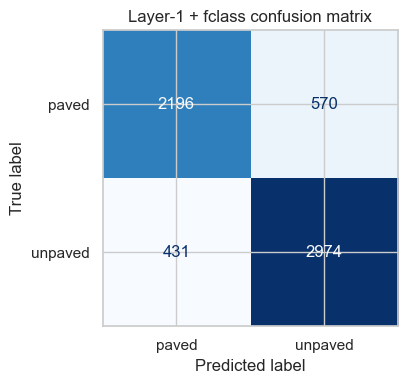

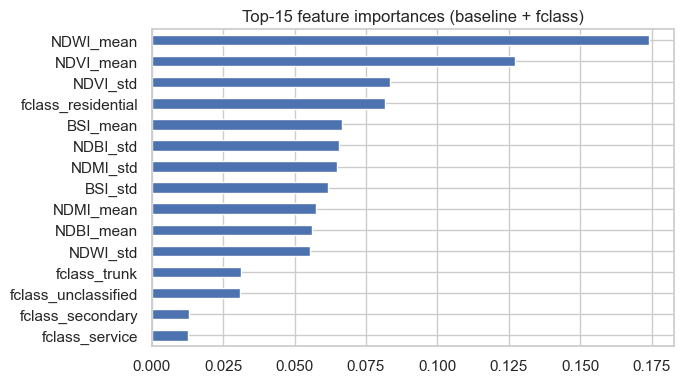

In [5]:
X = road_feats_large[feat_cols].copy()
y = road_feats_large["layer1_label_large"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print("Layer-1 + fclass report:")
print(classification_report(y_test, pred, digits=3))

cm = confusion_matrix(y_test, pred, labels=["paved", "unpaved"])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["paved", "unpaved"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Layer-1 + fclass confusion matrix")
plt.tight_layout()
plt.show()

imp = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
imp.head(15).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top-15 feature importances (baseline + fclass)")
plt.tight_layout()
plt.show()

## Comparison Note
Compare this notebook's metrics against your original 2020 RF notebook run.
If needed, we can add a side-by-side table in this notebook once you paste the baseline metrics.


In [6]:
# ---- Multi-year S2 loader ----
idx_cols = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
YEARS = [2017,2018,2019,2020, 2021, 2022, 2023]


def read_year_frames(year: int, base_dir: Path) -> pd.DataFrame:
    year_dir = base_dir / f"year={year}"
    if not year_dir.exists():
        raise FileNotFoundError(f"Missing year directory: {year_dir}")

    files = sorted(year_dir.glob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files in: {year_dir}")

    frames = []
    errors = []
    for f in files:
        try:
            temp = pd.read_parquet(f).copy()
            frames.append(temp)
        except Exception as e:
            errors.append((f.name, str(e)))

    if not frames:
        msg = "\n".join([f" - {name}: {err[:180]}" for name, err in errors])
        raise RuntimeError(f"Could not read any parquet files for year={year}.\n{msg}")

    out = pd.concat(frames, ignore_index=True)
    out["year"] = year
    return out


multi_frames = []
for y in YEARS:
    yf = read_year_frames(y, DATA_DIR / "ghana_parquet")
    yf["osm_id"] = yf["osm_id"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
    for c in idx_cols:
        yf[c] = pd.to_numeric(yf[c], errors="coerce")
    yf = yf.dropna(subset=idx_cols, how="all").copy()
    multi_frames.append(yf[["osm_id", "quarter", "year", *idx_cols]])

s2_multi = pd.concat(multi_frames, ignore_index=True)

print("Multi-year rows:", len(s2_multi))
print("Unique roads:", s2_multi["osm_id"].nunique())
print("Years present:", sorted(s2_multi["year"].dropna().unique().tolist()))
s2_multi.head(3)


Multi-year rows: 6375404
Unique roads: 326546
Years present: [2017, 2018, 2019, 2020, 2021, 2022, 2023]


,osm_id,quarter,year,NDVI,NDMI,NDBI,NDWI,BSI
0,574240962,Q1,2017,0.102122,-0.122559,0.122559,-0.191492,0.158831
1,574240965,Q1,2017,0.069340,-0.142151,0.142151,-0.160207,0.174891
2,574240966,Q1,2017,0.069755,-0.136570,0.136570,-0.163025,0.170579


Merged multi-year quarterly rows: 631461
Merged unique roads: 30851
Multi-year road-level rows: 30851
Feature count: 87

Layer-1 multi-year + fclass report:
              precision    recall  f1-score   support

       paved      0.876     0.854     0.865      2766
     unpaved      0.884     0.902     0.893      3405

    accuracy                          0.881      6171
   macro avg      0.880     0.878     0.879      6171
weighted avg      0.880     0.881     0.880      6171



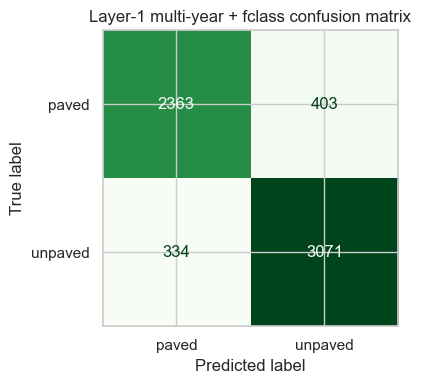

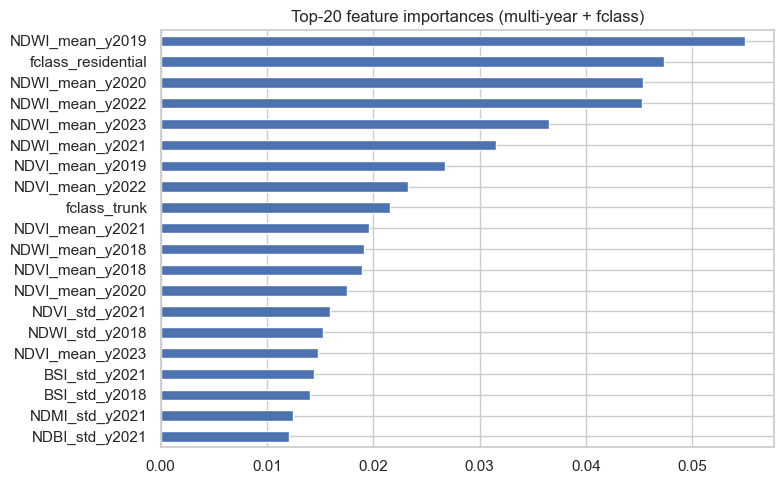

Top-15 important features:


,importance
NDWI_mean_y2019,0.054932
fclass_residential,0.047336
NDWI_mean_y2020,0.045386
NDWI_mean_y2022,0.045245
NDWI_mean_y2023,0.036477
NDWI_mean_y2021,0.031507
NDVI_mean_y2019,0.026770
NDVI_mean_y2022,0.023306
fclass_trunk,0.021573
NDVI_mean_y2021,0.019589


In [7]:
# ---- Build multi-year road features + train second RF ----
df_q_multi = s2_multi.merge(
    label_df_large[["osm_id", "layer1_label_large"]],
    on="osm_id",
    how="inner",
)

print("Merged multi-year quarterly rows:", len(df_q_multi))
print("Merged unique roads:", df_q_multi["osm_id"].nunique())

# 1) Aggregate per road+label+year
road_year = (
    df_q_multi.groupby(["osm_id", "layer1_label_large", "year"], as_index=False)
    .agg(
        NDVI_mean=("NDVI", "mean"), NDVI_std=("NDVI", "std"),
        NDMI_mean=("NDMI", "mean"), NDMI_std=("NDMI", "std"),
        NDBI_mean=("NDBI", "mean"), NDBI_std=("NDBI", "std"),
        NDWI_mean=("NDWI", "mean"), NDWI_std=("NDWI", "std"),
        BSI_mean=("BSI", "mean"),  BSI_std=("BSI", "std"),
    )
)

# 2) Pivot to wide format
mean_cols = ["NDVI_mean", "NDMI_mean", "NDBI_mean", "NDWI_mean", "BSI_mean"]
std_cols = ["NDVI_std", "NDMI_std", "NDBI_std", "NDWI_std", "BSI_std"]

means_wide = road_year.pivot(index=["osm_id", "layer1_label_large"], columns="year", values=mean_cols)
std_wide = road_year.pivot(index=["osm_id", "layer1_label_large"], columns="year", values=std_cols)

means_wide.columns = [f"{m}_y{y}" for (m, y) in means_wide.columns]
std_wide.columns = [f"{m}_y{y}" for (m, y) in std_wide.columns]

road_multi = pd.concat([means_wide, std_wide], axis=1).reset_index()

# 3) Delta and slope features
for idx in ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]:
    y20 = f"{idx}_mean_y2020"
    y21 = f"{idx}_mean_y2021"
    y22 = f"{idx}_mean_y2022"
    y23 = f"{idx}_mean_y2023"

    if all(c in road_multi.columns for c in [y20, y21, y22, y23]):
        road_multi[f"{idx}_delta_2023_2020"] = road_multi[y23] - road_multi[y20]

        def slope4(row):
            vals = np.array([row[y20], row[y21], row[y22], row[y23]], dtype=float)
            mask = ~np.isnan(vals)
            if mask.sum() < 3:
                return np.nan
            x = np.arange(4)[mask]
            return np.polyfit(x, vals[mask], 1)[0]

        road_multi[f"{idx}_slope_year"] = road_multi.apply(slope4, axis=1)

# 4) Merge fclass back in from baseline section
road_multi = road_multi.merge(fclass_lookup, on="osm_id", how="left")
for c in fclass_cols:
    road_multi[c] = road_multi[c].fillna(0).astype(int)

# Fill remaining NaN
num_cols = [c for c in road_multi.columns if c not in ["osm_id", "layer1_label_large"]]
road_multi[num_cols] = road_multi[num_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

print("Multi-year road-level rows:", len(road_multi))
print("Feature count:", len(num_cols))

X2 = road_multi[num_cols].copy()
y2 = road_multi["layer1_label_large"].copy()

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

rf_multi = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)
rf_multi.fit(X2_train, y2_train)
pred2 = rf_multi.predict(X2_test)
proba2 = rf_multi.predict_proba(X2_test)

print("\nLayer-1 multi-year + fclass report:")
print(classification_report(y2_test, pred2, digits=3))

cm2 = confusion_matrix(y2_test, pred2, labels=["paved", "unpaved"])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm2, display_labels=["paved", "unpaved"]).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Layer-1 multi-year + fclass confusion matrix")
plt.tight_layout()
plt.show()

imp2 = pd.Series(rf_multi.feature_importances_, index=num_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
imp2.head(20).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top-20 feature importances (multi-year + fclass)")
plt.tight_layout()
plt.show()

print("Top-15 important features:")
display(imp2.head(15).to_frame("importance"))

Enhanced temporal RF report:
              precision    recall  f1-score   support

       paved      0.878     0.855     0.866      2766
     unpaved      0.884     0.903     0.894      3405

    accuracy                          0.882      6171
   macro avg      0.881     0.879     0.880      6171
weighted avg      0.881     0.882     0.881      6171



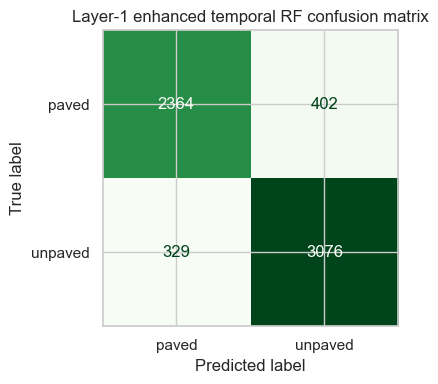

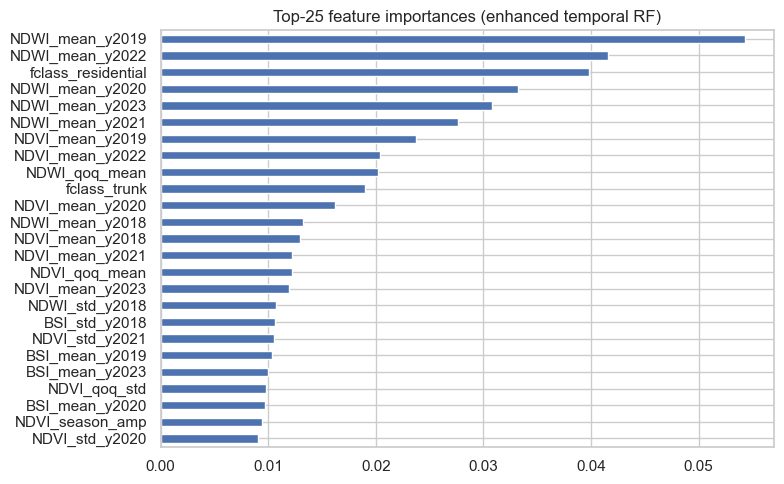

Top-20 important features (enhanced temporal RF):


,importance
NDWI_mean_y2019,0.054279
NDWI_mean_y2022,0.041595
fclass_residential,0.039795
NDWI_mean_y2020,0.033226
NDWI_mean_y2023,0.030831
NDWI_mean_y2021,0.027633
NDVI_mean_y2019,0.023773
NDVI_mean_y2022,0.020353
NDWI_qoq_mean,0.020239
fclass_trunk,0.018952


Feature count (enhanced): 125


In [8]:
# ---- Enhanced temporal feature engineering from quarterly series ----
# Uses df_q_multi from section 5 (merged quarterly S2 + labels).

idx_cols = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
quarter_order = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4}

tmp = df_q_multi.copy()
tmp["q_num"] = tmp["quarter"].map(quarter_order)
tmp = tmp.dropna(subset=["q_num"]).copy()
tmp["time_idx"] = (tmp["year"] - tmp["year"].min()) * 4 + (tmp["q_num"] - 1)

group_keys = ["osm_id", "layer1_label_large"]

# Start from existing multi-year feature table to keep comparability.
rf_temporal = road_multi.copy()


def add_series_features(base_df, signal_name):
    s = tmp[group_keys + ["time_idx", "q_num", signal_name]].dropna(subset=[signal_name]).copy()

    # linear slope over all quarters
    def slope_fn(g):
        if len(g) < 4:
            return np.nan
        x = g["time_idx"].to_numpy(dtype=float)
        y = g[signal_name].to_numpy(dtype=float)
        if np.all(np.isclose(y, y[0])):
            return 0.0
        return float(np.polyfit(x, y, 1)[0])

    slope = s.groupby(group_keys, as_index=False).apply(slope_fn, include_groups=False)
    slope = slope.rename(columns={None: f"{signal_name}_slope_q"})

    # quarter-to-quarter diffs
    s = s.sort_values(group_keys + ["time_idx"])
    s["diff"] = s.groupby(group_keys)[signal_name].diff()

    qoq_stats = s.groupby(group_keys, as_index=False).agg(
        **{
            f"{signal_name}_qoq_mean": ("diff", "mean"),
            f"{signal_name}_qoq_std": ("diff", "std"),
            f"{signal_name}_qoq_max_rise": ("diff", "max"),
            f"{signal_name}_qoq_max_drop": ("diff", "min"),
        }
    )

    # seasonality: wet vs dry contrast proxy (Q2/Q3 vs Q1/Q4)
    season = s.groupby(group_keys + ["q_num"], as_index=False)[signal_name].mean()
    season_p = season.pivot(index=group_keys, columns="q_num", values=signal_name)
    season_p.columns = [f"q{int(c)}" for c in season_p.columns]
    season_p = season_p.reset_index()

    for q in [1,2,3,4]:
        c=f"q{q}"
        if c not in season_p.columns:
            season_p[c]=np.nan

    season_p[f"{signal_name}_wet_dry_delta"] = season_p[["q2","q3"]].mean(axis=1) - season_p[["q1","q4"]].mean(axis=1)
    season_p[f"{signal_name}_season_amp"] = season_p[["q1","q2","q3","q4"]].max(axis=1) - season_p[["q1","q2","q3","q4"]].min(axis=1)

    keep_cols = group_keys + [
        f"{signal_name}_wet_dry_delta",
        f"{signal_name}_season_amp",
    ]
    season_feats = season_p[keep_cols]

    out = base_df.merge(slope, on=group_keys, how="left")
    out = out.merge(qoq_stats, on=group_keys, how="left")
    out = out.merge(season_feats, on=group_keys, how="left")
    return out


for idx in idx_cols:
    rf_temporal = add_series_features(rf_temporal, idx)

# Cross-index temporal interactions (simple but useful)
for a,b in [("NDBI","NDVI"), ("BSI","NDMI"), ("NDWI","NDMI")]:
    ca = f"{a}_slope_q"
    cb = f"{b}_slope_q"
    if ca in rf_temporal.columns and cb in rf_temporal.columns:
        rf_temporal[f"{a}_{b}_slope_gap"] = rf_temporal[ca] - rf_temporal[cb]

# Final model table
feature_cols_temporal = [c for c in rf_temporal.columns if c not in ["osm_id", "layer1_label_large"]]
rf_temporal[feature_cols_temporal] = rf_temporal[feature_cols_temporal].apply(pd.to_numeric, errors="coerce").fillna(0)

X3 = rf_temporal[feature_cols_temporal].copy()
y3 = rf_temporal["layer1_label_large"].copy()

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

rf_temporal_model = RandomForestClassifier(
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)
rf_temporal_model.fit(X3_train, y3_train)
pred3 = rf_temporal_model.predict(X3_test)

print("Enhanced temporal RF report:")
print(classification_report(y3_test, pred3, digits=3))

cm3 = confusion_matrix(y3_test, pred3, labels=["paved", "unpaved"])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm3, display_labels=["paved", "unpaved"]).plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Layer-1 enhanced temporal RF confusion matrix")
plt.tight_layout()
plt.show()

imp3 = pd.Series(rf_temporal_model.feature_importances_, index=feature_cols_temporal).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
imp3.head(25).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top-25 feature importances (enhanced temporal RF)")
plt.tight_layout()
plt.show()

print("Top-20 important features (enhanced temporal RF):")
display(imp3.head(20).to_frame("importance"))
print("Feature count (enhanced):", len(feature_cols_temporal))


XGBoost report (enhanced temporal, no graph):
              precision    recall  f1-score   support

       paved      0.876     0.866     0.871      2766
     unpaved      0.892     0.901     0.896      3405

    accuracy                          0.885      6171
   macro avg      0.884     0.883     0.884      6171
weighted avg      0.885     0.885     0.885      6171



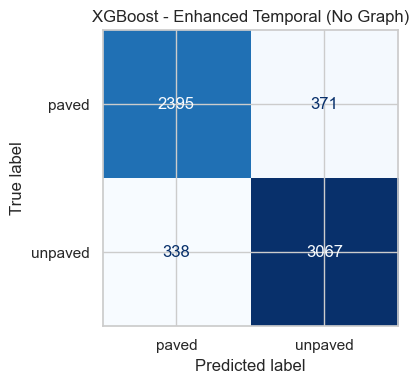

,importance
NDWI_mean_y2019,0.102383
fclass_residential,0.095513
fclass_trunk,0.066408
NDWI_mean_y2022,0.049927
fclass_unclassified,0.035419
fclass_service,0.033863
NDWI_mean_y2020,0.019320
fclass_primary,0.019002
fclass_secondary,0.017454
BSI_qoq_std,0.017160


In [9]:
# ---- XGBoost directly on enhanced temporal features (no graph) ----
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

try:
    from xgboost import XGBClassifier
except Exception as e:
    raise ImportError("xgboost is not installed. Install with: pip install xgboost") from e

if 'rf_temporal' not in globals():
    raise ValueError("rf_temporal not found. Run enhanced temporal section first.")

# Use unique variable names so nothing downstream is overwritten
xgb_temp_df = rf_temporal.copy()
xgb_temp_df['osm_id'] = xgb_temp_df['osm_id'].astype(str)

xgb_temp_feature_cols = [c for c in xgb_temp_df.columns if c not in ['osm_id', 'layer1_label_large']]
X_temp = xgb_temp_df[xgb_temp_feature_cols].apply(pd.to_numeric, errors='coerce')
y_temp = xgb_temp_df['layer1_label_large'].copy()

# median impute for XGBoost
med_temp = X_temp.median(numeric_only=True)
X_temp = X_temp.fillna(med_temp).fillna(0)

Xtr_temp, Xte_temp, ytr_temp, yte_temp = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

label_map_temp = {'paved': 0, 'unpaved': 1}
inv_label_map_temp = {0: 'paved', 1: 'unpaved'}

ytr_num_temp = ytr_temp.map(label_map_temp)
neg_temp = int((ytr_num_temp == 0).sum())
pos_temp = int((ytr_num_temp == 1).sum())
spw_temp = (neg_temp / pos_temp) if pos_temp > 0 else 1.0

xgb_temporal_model = XGBClassifier(
    n_estimators=900,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    min_child_weight=2,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=spw_temp,
    random_state=42,
    n_jobs=-1,
)

xgb_temporal_model.fit(Xtr_temp, ytr_num_temp)
pred_num_temp = xgb_temporal_model.predict(Xte_temp)
pred_lbl_temp = pd.Series(pred_num_temp).map(inv_label_map_temp).values

print("XGBoost report (enhanced temporal, no graph):")
print(classification_report(yte_temp, pred_lbl_temp, digits=3))

cm_temp = confusion_matrix(yte_temp, pred_lbl_temp, labels=['paved', 'unpaved'])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_temp, display_labels=['paved', 'unpaved']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('XGBoost - Enhanced Temporal (No Graph)')
plt.tight_layout()
plt.show()

imp_temp = pd.Series(xgb_temporal_model.feature_importances_, index=xgb_temp_feature_cols).sort_values(ascending=False)
display(imp_temp.head(25).to_frame('importance'))

Segments in graph scope: 30851
Segments with >=1 neighbor: 28482
Median degree: 2.0
Graph-neighbor + fclass RF report:
              precision    recall  f1-score   support

       paved      0.882     0.847     0.864      2766
     unpaved      0.880     0.908     0.894      3405

    accuracy                          0.881      6171
   macro avg      0.881     0.878     0.879      6171
weighted avg      0.881     0.881     0.881      6171



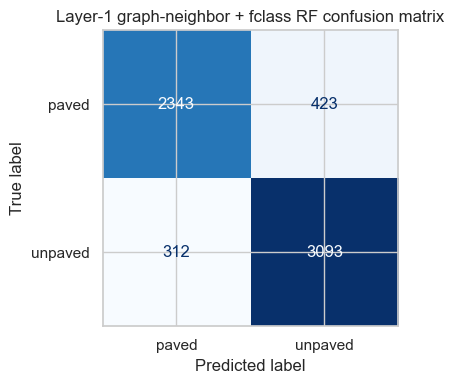

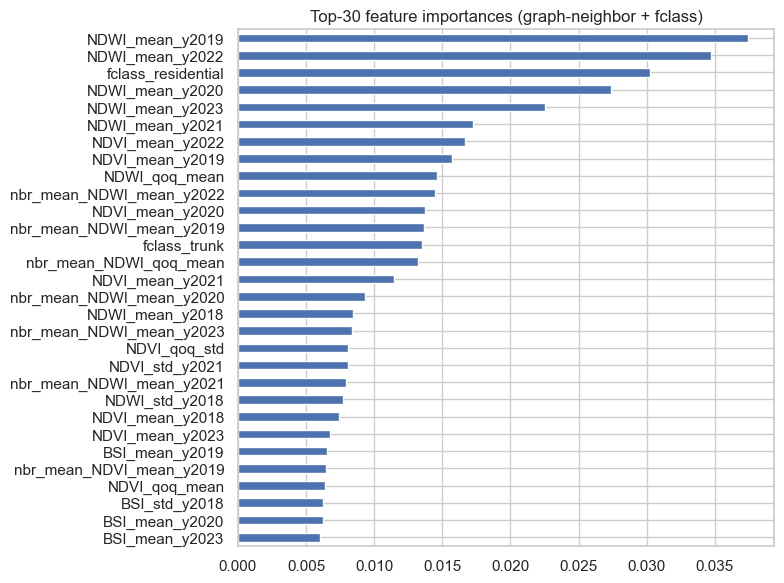

Top-20 important features:


,importance
NDWI_mean_y2019,0.037477
NDWI_mean_y2022,0.034740
fclass_residential,0.030276
NDWI_mean_y2020,0.027420
NDWI_mean_y2023,0.022534
NDWI_mean_y2021,0.017232
NDVI_mean_y2022,0.016698
NDVI_mean_y2019,0.015740
NDWI_qoq_mean,0.014601
nbr_mean_NDWI_mean_y2022,0.014485


Feature count: 228


In [10]:
# ---- Graph neighbors from shared geometry endpoints ----
# Requires: roads_osm (with geometry), rf_temporal from section 6.

from collections import defaultdict

if 'geometry' not in roads_osm.columns:
    raise ValueError('roads_osm geometry missing; rerun section 2 first.')

model_ids = set(rf_temporal['osm_id'].astype(str))
road_geom = roads_osm[roads_osm['osm_id'].astype(str).isin(model_ids)][['osm_id','geometry']].copy()
road_geom['osm_id'] = road_geom['osm_id'].astype(str)

def endpoints_of_geom(g):
    if g is None or g.is_empty:
        return []
    pts = []
    if g.geom_type == 'LineString':
        coords = list(g.coords)
        if len(coords) >= 2:
            pts = [coords[0], coords[-1]]
    elif g.geom_type == 'MultiLineString':
        for part in g.geoms:
            coords = list(part.coords)
            if len(coords) >= 2:
                pts.extend([coords[0], coords[-1]])
    return [(round(x, 6), round(y, 6)) for x, y in pts]

node_to_ids = defaultdict(set)
for oid, geom in zip(road_geom['osm_id'], road_geom['geometry']):
    for node in endpoints_of_geom(geom):
        node_to_ids[node].add(oid)

neighbors = defaultdict(set)
for ids in node_to_ids.values():
    if len(ids) < 2:
        continue
    ids_list = list(ids)
    for i in range(len(ids_list)):
        for j in range(i+1, len(ids_list)):
            neighbors[ids_list[i]].add(ids_list[j])
            neighbors[ids_list[j]].add(ids_list[i])

degree_df = pd.DataFrame({
    'osm_id': rf_temporal['osm_id'].astype(str),
    'nbr_degree': rf_temporal['osm_id'].astype(str).map(lambda x: len(neighbors.get(x, set()))),
})

print('Segments in graph scope:', len(road_geom))
print('Segments with >=1 neighbor:', int((degree_df['nbr_degree'] > 0).sum()))
print('Median degree:', float(degree_df['nbr_degree'].median()))

base = rf_temporal.copy()
base['osm_id'] = base['osm_id'].astype(str)
num_cols = [c for c in base.columns if c not in ['osm_id', 'layer1_label_large']]

priority = [c for c in num_cols if any(k in c for k in [
    'NDWI_mean_y', 'NDVI_mean_y', 'BSI_mean_y',
    '_slope_q', '_qoq_mean', '_qoq_std', '_wet_dry_delta', '_season_amp',
    'delta_2023_2020'
])]
if len(priority) < 20:
    priority = num_cols[:min(40, len(num_cols))]

feat_lookup = base.set_index('osm_id')[priority]

agg_rows = []
for oid in base['osm_id']:
    nbrs = list(neighbors.get(oid, set()))
    row = {'osm_id': oid}
    if nbrs:
        sub = feat_lookup.reindex(nbrs)
        for c in priority:
            row[f'nbr_mean_{c}'] = sub[c].mean(skipna=True)
            row[f'nbr_std_{c}'] = sub[c].std(skipna=True)
    else:
        for c in priority:
            row[f'nbr_mean_{c}'] = np.nan
            row[f'nbr_std_{c}'] = np.nan
    agg_rows.append(row)

nbr_feats = pd.DataFrame(agg_rows)

rf_graph = base.merge(degree_df, on='osm_id', how='left').merge(nbr_feats, on='osm_id', how='left')
rf_graph = rf_graph.fillna(0)

feature_cols_graph = [c for c in rf_graph.columns if c not in ['osm_id', 'layer1_label_large']]

Xg = rf_graph[feature_cols_graph].copy()
yg = rf_graph['layer1_label_large'].copy()

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    Xg, yg, test_size=0.2, random_state=42, stratify=yg
)

rf_graph_model = RandomForestClassifier(
    n_estimators=900,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample',
)
rf_graph_model.fit(Xg_train, yg_train)
predg = rf_graph_model.predict(Xg_test)

print('Graph-neighbor + fclass RF report:')
print(classification_report(yg_test, predg, digits=3))

cmg = confusion_matrix(yg_test, predg, labels=['paved', 'unpaved'])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cmg, display_labels=['paved', 'unpaved']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Layer-1 graph-neighbor + fclass RF confusion matrix')
plt.tight_layout()
plt.show()

impg = pd.Series(rf_graph_model.feature_importances_, index=feature_cols_graph).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
impg.head(30).sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top-30 feature importances (graph-neighbor + fclass)')
plt.tight_layout()
plt.show()

print('Top-20 important features:')
display(impg.head(20).to_frame('importance'))
print('Feature count:', len(feature_cols_graph))

XGBoost report (graph-neighbor + fclass):
              precision    recall  f1-score   support

       paved      0.886     0.881     0.884      2766
     unpaved      0.904     0.908     0.906      3405

    accuracy                          0.896      6171
   macro avg      0.895     0.895     0.895      6171
weighted avg      0.896     0.896     0.896      6171



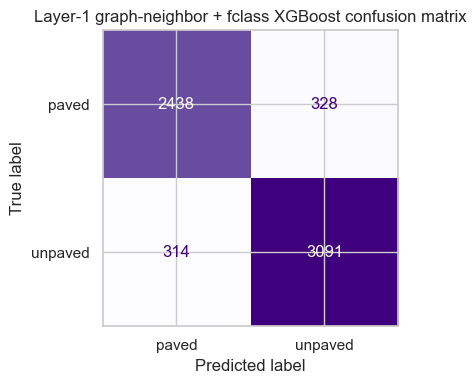

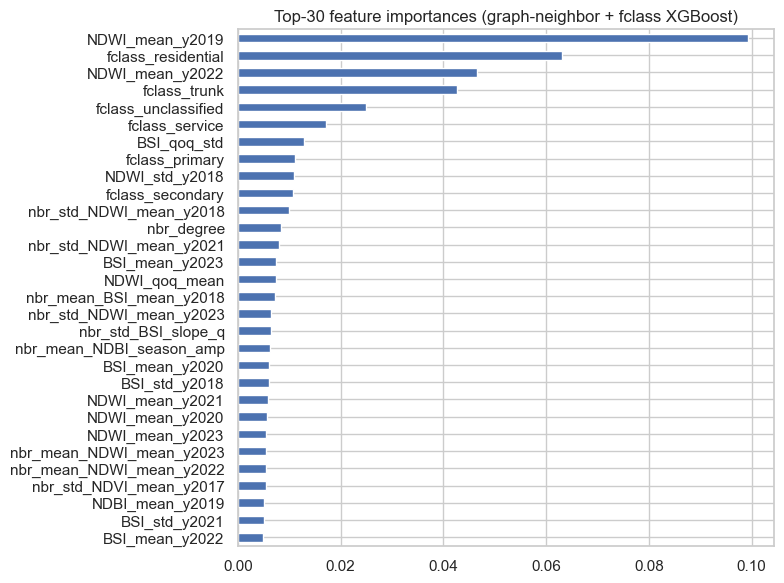

Top-20 important features (XGBoost):


,importance
NDWI_mean_y2019,0.099367
fclass_residential,0.063143
NDWI_mean_y2022,0.046623
fclass_trunk,0.042576
fclass_unclassified,0.024982
fclass_service,0.017224
BSI_qoq_std,0.012790
fclass_primary,0.011065
NDWI_std_y2018,0.011006
fclass_secondary,0.010664


In [11]:
# ---- XGBoost on graph-neighbor + fclass features ----
from sklearn.model_selection import GroupKFold
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

if 'rf_graph' not in globals() or 'feature_cols_graph' not in globals():
    raise ValueError('Run section 7 (graph-neighbor RF) first to create rf_graph/feature_cols_graph.')

Xg = rf_graph[feature_cols_graph].copy()
yg = rf_graph['layer1_label_large'].copy()

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    Xg, yg, test_size=0.2, random_state=42, stratify=yg
)

try:
    from xgboost import XGBClassifier
except Exception as e:
    raise ImportError('xgboost is not installed. Install with: pip install xgboost') from e

label_map = {'paved': 0, 'unpaved': 1}
inv_label_map = {0: 'paved', 1: 'unpaved'}

yg_train_num = yg_train.map(label_map)
yg_test_num = yg_test.map(label_map)

neg = int((yg_train_num == 0).sum())
pos = int((yg_train_num == 1).sum())
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

xgb_model = XGBClassifier(
    n_estimators=900,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    min_child_weight=2,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(Xg_train, yg_train_num)
pred_num = xgb_model.predict(Xg_test)
pred_lbl = pd.Series(pred_num).map(inv_label_map).values

print('XGBoost report (graph-neighbor + fclass):')
print(classification_report(yg_test, pred_lbl, digits=3))

cmx = confusion_matrix(yg_test, pred_lbl, labels=['paved', 'unpaved'])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cmx, display_labels=['paved', 'unpaved']).plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title('Layer-1 graph-neighbor + fclass XGBoost confusion matrix')
plt.tight_layout()
plt.show()

impx = pd.Series(xgb_model.feature_importances_, index=feature_cols_graph).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
impx.head(30).sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top-30 feature importances (graph-neighbor + fclass XGBoost)')
plt.tight_layout()
plt.show()

print('Top-20 important features (XGBoost):')
display(impx.head(20).to_frame('importance'))

In [21]:
# ---- Grouped CV benchmark on graph-neighbor + fclass feature set ----
from sklearn.model_selection import GroupKFold
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

if 'rf_graph' not in globals():
    raise ValueError('rf_graph not found. Run section 7 (graph neighbors) first.')

bench_df = rf_graph.copy()
bench_df['osm_id'] = bench_df['osm_id'].astype(str)

name_lookup = roads_osm[['osm_id', 'name']].copy()
name_lookup['osm_id'] = name_lookup['osm_id'].astype(str)
name_lookup['name_clean'] = name_lookup['name'].astype(str).str.strip().replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
name_lookup = name_lookup[['osm_id', 'name_clean']].drop_duplicates(subset=['osm_id'])

bench_df = bench_df.merge(name_lookup, on='osm_id', how='left')
bench_df['group_id'] = np.where(bench_df['name_clean'].notna(), 'name::' + bench_df['name_clean'].astype(str), 'osm::' + bench_df['osm_id'])

feature_cols_bench = [c for c in bench_df.columns if c not in ['osm_id', 'layer1_label_large', 'name_clean', 'group_id']]
Xb = bench_df[feature_cols_bench].apply(pd.to_numeric, errors='coerce').fillna(0)
yb = bench_df['layer1_label_large'].copy()
groups = bench_df['group_id'].copy()

print('Benchmark rows:', len(bench_df))
print('Unique groups:', groups.nunique())
print('Class balance (%):')
print(yb.value_counts(normalize=True).mul(100).round(2))

models = {
    'rf': RandomForestClassifier(
        n_estimators=900, random_state=42, min_samples_leaf=2, n_jobs=-1, class_weight='balanced_subsample',
    ),
    'logistic': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(random_state=42, class_weight='balanced', max_iter=3000)),
    ]),
}

xgb_available = True
try:
    from xgboost import XGBClassifier
except Exception:
    xgb_available = False

if xgb_available:
    models['xgboost'] = XGBClassifier(
        n_estimators=700, max_depth=6, learning_rate=0.05, subsample=0.9,
        colsample_bytree=0.9, reg_lambda=1.0, objective='binary:logistic',
        eval_metric='logloss', random_state=42, n_jobs=-1,
    )


if lgbm_available:
    models['lightgbm'] = LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        random_state=42, n_jobs=-1, verbose=-1,
    )

label_map = {'unpaved': 1, 'paved': 0}
inv_label_map = {v: k for k, v in label_map.items()}

cv = GroupKFold(n_splits=5)
rows = []

for model_name, model in models.items():
    fold_no = 0
    for tr_idx, te_idx in cv.split(Xb, yb, groups=groups):
        fold_no += 1
        Xtr, Xte = Xb.iloc[tr_idx], Xb.iloc[te_idx]
        ytr, yte = yb.iloc[tr_idx], yb.iloc[te_idx]

        if model_name == 'xgboost':
            ytr_num = ytr.map(label_map)
            model.fit(Xtr, ytr_num)
            pred_num = model.predict(Xte)
            pred = pd.Series(pred_num).map(inv_label_map).values
            yt = yte.values
        else:
            model.fit(Xtr, ytr)
            pred = model.predict(Xte)
            yt = yte.values

        p, r, f1, _ = precision_recall_fscore_support(yt, pred, labels=['paved', 'unpaved'], zero_division=0)
        acc = accuracy_score(yt, pred)
        mcc = matthews_corrcoef(yt, pred)
        rows.append({
            'model': model_name, 'fold': fold_no, 'accuracy': acc,
            'paved_precision': p[0], 'paved_recall': r[0], 'paved_f1': f1[0],
            'unpaved_precision': p[1], 'unpaved_recall': r[1], 'unpaved_f1': f1[1],
            'macro_f1': (f1[0] + f1[1]) / 2.0,
            'mcc': mcc,
        })
        # Save last fold data for permutation importance / SHAP
        Xte_last, yte_last, model_last, model_name_last = Xte, yte, model, model_name

cv_results = pd.DataFrame(rows)
summary = (
    cv_results.groupby('model', as_index=False)
    .agg(
        accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
        paved_f1_mean=('paved_f1', 'mean'), paved_f1_std=('paved_f1', 'std'),
        unpaved_f1_mean=('unpaved_f1', 'mean'), unpaved_f1_std=('unpaved_f1', 'std'),
        macro_f1_mean=('macro_f1', 'mean'), macro_f1_std=('macro_f1', 'std'),
        paved_recall_mean=('paved_recall', 'mean'),
        unpaved_recall_mean=('unpaved_recall', 'mean'),
    )
    .sort_values('macro_f1_mean', ascending=False)
)

# Store Stage 2 RF per-fold macro-F1 for Wilcoxon test
stage2_f1s = cv_results[cv_results['model'] == 'rf']['macro_f1'].tolist()

print('Grouped CV summary (mean ± std):')
display(summary)
print('\nFold-by-fold results:')
display(cv_results.sort_values(['model', 'fold']))

Benchmark rows: 30851
Unique groups: 25365
Class balance (%):
layer1_label_large
unpaved    55.17
paved      44.83
Name: proportion, dtype: float64
Grouped CV summary (mean ± std):


,model,accuracy_mean,accuracy_std,paved_f1_mean,paved_f1_std,unpaved_f1_mean,unpaved_f1_std,macro_f1_mean,macro_f1_std,paved_recall_mean,unpaved_recall_mean
3,xgboost,0.893974,0.002983,0.879891,0.004574,0.905079,0.002232,0.892485,0.003215,0.866646,0.916181
0,lightgbm,0.892937,0.003141,0.878688,0.004700,0.904166,0.002469,0.891427,0.003358,0.865265,0.915423
2,rf,0.872581,0.002329,0.855023,0.003550,0.886329,0.002005,0.870676,0.002480,0.838371,0.900454
1,logistic,0.849437,0.006765,0.833901,0.009986,0.862257,0.004829,0.848079,0.007190,0.843763,0.853953



Fold-by-fold results:


,model,fold,accuracy,paved_precision,paved_recall,paved_f1,unpaved_precision,unpaved_recall,unpaved_f1,macro_f1,mcc
15,lightgbm,1,0.898396,0.905236,0.869027,0.886762,0.893033,0.923192,0.907862,0.897312,0.795238
16,lightgbm,2,0.891086,0.883721,0.873563,0.878613,0.897016,0.905493,0.901235,0.889924,0.779896
17,lightgbm,3,0.892707,0.885307,0.869021,0.877089,0.898344,0.911356,0.904803,0.890946,0.782012
18,lightgbm,4,0.891734,0.898473,0.854136,0.875744,0.886761,0.922086,0.904078,0.889911,0.780715
19,lightgbm,5,0.890762,0.890395,0.860575,0.875231,0.891038,0.914987,0.902854,0.889043,0.778492
5,logistic,1,0.856425,0.837217,0.852035,0.844561,0.873180,0.860132,0.866606,0.855584,0.711281
6,logistic,2,0.852188,0.819236,0.862787,0.840448,0.882026,0.843473,0.862319,0.851383,0.703757
7,logistic,3,0.843760,0.817984,0.830022,0.823959,0.864596,0.854577,0.859557,0.841758,0.683589
8,logistic,4,0.853971,0.830895,0.845065,0.837920,0.873181,0.861160,0.867129,0.852525,0.705150
9,logistic,5,0.840843,0.816422,0.828904,0.822616,0.860988,0.850424,0.855673,0.839144,0.678368


Best model by macro-F1: xgboost
Computing permutation importance on last held-out fold...


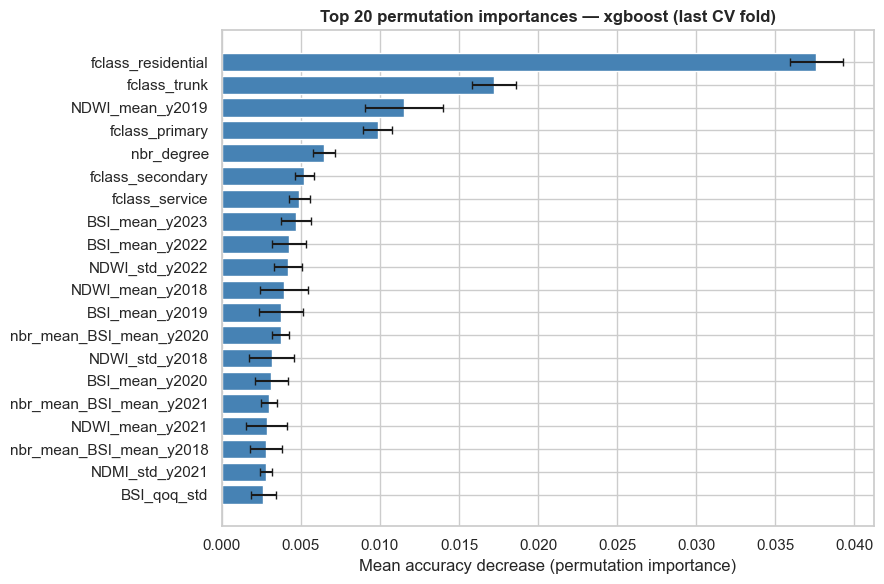

,feature,importance_mean,importance_std
0,fclass_residential,0.0376,0.0017
1,fclass_trunk,0.0172,0.0014
2,NDWI_mean_y2019,0.0115,0.0025
3,fclass_primary,0.0099,0.0009
4,nbr_degree,0.0064,0.0007
5,fclass_secondary,0.0052,0.0006
6,fclass_service,0.0049,0.0007
7,BSI_mean_y2023,0.0047,0.0009
8,BSI_mean_y2022,0.0042,0.0011
9,NDWI_std_y2022,0.0042,0.0009


In [22]:
# ---- Permutation importance on best model (last CV fold) ----
# Uses held-out data from the last GroupKFold split.
# More reliable than gain-based importance for correlated features.

best_model_name = summary.iloc[0]['model']
print(f'Best model by macro-F1: {best_model_name}')
print('Computing permutation importance on last held-out fold...')

# Get the best model's last-fold instance
# Re-run last fold for best model to ensure we have the right model object
best_model_obj = models[best_model_name]
last_fold_splits = list(cv.split(Xb, yb, groups=groups))
tr_last, te_last = last_fold_splits[-1]
Xtr_perm = Xb.iloc[tr_last]
Xte_perm = Xb.iloc[te_last]
ytr_perm = yb.iloc[tr_last]
yte_perm = yb.iloc[te_last]

if best_model_name == 'xgboost':
    best_model_obj.fit(Xtr_perm, ytr_perm.map(label_map))
    score_fn = lambda est, X, y: accuracy_score(y, pd.Series(est.predict(X)).map(inv_label_map).values)
else:
    best_model_obj.fit(Xtr_perm, ytr_perm)
    score_fn = None  # uses default scorer

result = permutation_importance(
    best_model_obj, Xte_perm, yte_perm if best_model_name != 'xgboost' else yte_perm.map(label_map),
    n_repeats=10, random_state=42, n_jobs=-1,
    scoring='accuracy',
)

perm_df = pd.DataFrame({
    'feature': feature_cols_bench,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std,
}).sort_values('importance_mean', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_df['feature'][::-1], perm_df['importance_mean'][::-1],
        xerr=perm_df['importance_std'][::-1],
        color='steelblue', edgecolor='white', capsize=3)
ax.set_xlabel('Mean accuracy decrease (permutation importance)')
ax.set_title(f'Top 20 permutation importances — {best_model_name} (last CV fold)', fontweight='bold')
plt.tight_layout()
plt.show()
display(perm_df.reset_index(drop=True).round(4))


SHAP summary plot — xgboost on 500 samples 


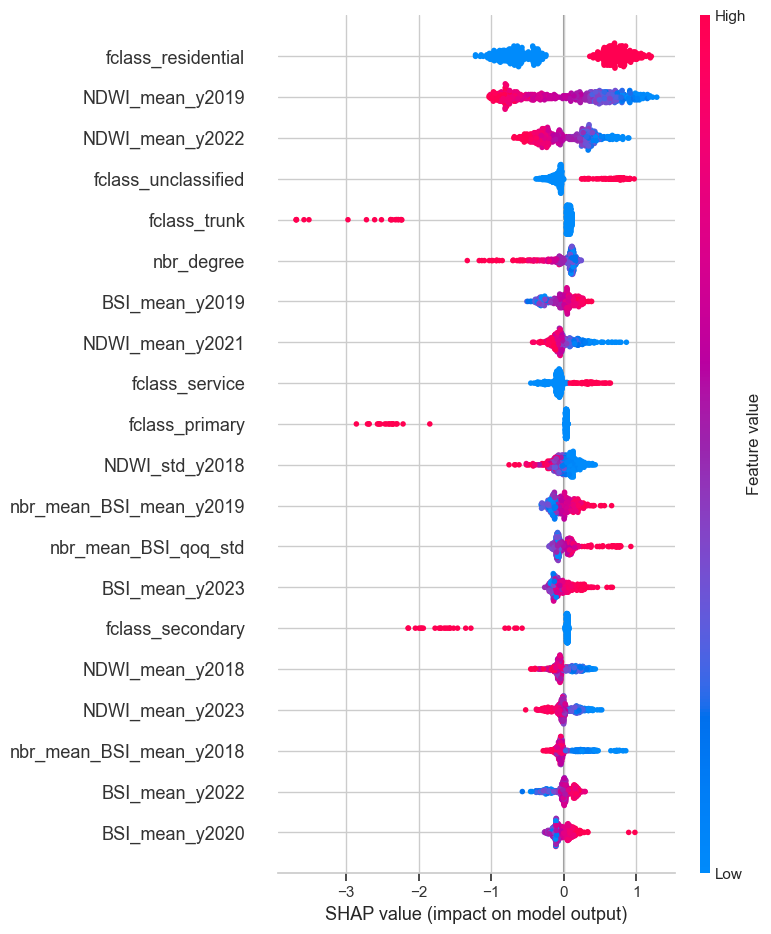

In [23]:
# ---- SHAP values — best model fitted on full training set ----
if not shap_available:
    print('SHAP not available. Install with: pip install shap')
else:
    # Fit best model on all labelled data
    shap_model = models[best_model_name]
    if best_model_name == 'xgboost':
        shap_model.fit(Xb, yb.map(label_map))
    else:
        shap_model.fit(Xb, yb)

    # Compute SHAP on a 500-sample random subset
    n_shap = min(500, len(Xb))
    rng = np.random.default_rng(42)
    shap_idx = rng.choice(len(Xb), size=n_shap, replace=False)
    X_shap = Xb.iloc[shap_idx]

    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_shap)

    # For binary classifiers TreeExplainer may return a list [class0, class1]
    if isinstance(shap_values, list):
        shap_vals_plot = shap_values[1]  # unpaved class
        title_suffix = '(unpaved class)'
    else:
        shap_vals_plot = shap_values
        title_suffix = ''

    print(f'SHAP summary plot — {best_model_name} on {n_shap} samples {title_suffix}')
    shap.summary_plot(shap_vals_plot, X_shap, feature_names=feature_cols_bench,
                      plot_type='dot', show=True, max_display=20)


In [25]:
# ---- Wilcoxon signed-rank test: Stage 2 (S2 + fclass) vs Stage 1 (S2 only) ----
# stage2_f1s collected above from RF CV folds.
# stage1_f1s must be set from the earlier S2-only notebook (cell 10 / layer1.ipynb).
# Example: stage1_f1s = [0.81, 0.83, 0.82, 0.80, 0.84]

stage1_f1s = [0.848814, 0.859067, 0.847317, 0.847683, 0.862072]

print('Stage 2 (S2 + fclass) per-fold macro-F1:', [round(v,4) for v in stage2_f1s])

if 'stage1_f1s' not in globals():
    print()
    print('stage1_f1s not found in globals.')
    print('Set it from the Stage 1 (S2-only) CV run, e.g.:')
    print('  stage1_f1s = [f1_fold1, f1_fold2, f1_fold3, f1_fold4, f1_fold5]')
    print('Then re-run this cell.')
elif len(stage1_f1s) != len(stage2_f1s):
    print(f'Length mismatch: stage1={len(stage1_f1s)}, stage2={len(stage2_f1s)}. Both must have same number of folds.')
else:
    stat, p = wilcoxon(stage2_f1s, stage1_f1s, alternative='greater')
    print('Stage 1 (S2 only)   per-fold macro-F1:', [round(v,4) for v in stage1_f1s])
    delta = np.mean(stage2_f1s) - np.mean(stage1_f1s)
    print(f'\nMean delta (Stage2 - Stage1): {delta:+.4f}')
    print(f'Wilcoxon statistic: {stat:.4f}')
    print(f'p-value (one-sided, Stage2 > Stage1): {p:.4f}')
    if p < 0.05:
        print('→ Statistically significant improvement (p < 0.05).')
    else:
        print('→ Not statistically significant at p < 0.05.')


Stage 2 (S2 + fclass) per-fold macro-F1: [0.8705, 0.8731, 0.8725, 0.8705, 0.8668]
Stage 1 (S2 only)   per-fold macro-F1: [0.8488, 0.8591, 0.8473, 0.8477, 0.8621]

Mean delta (Stage2 - Stage1): +0.0177
Wilcoxon statistic: 15.0000
p-value (one-sided, Stage2 > Stage1): 0.0312
→ Statistically significant improvement (p < 0.05).
